In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
data = pd.read_csv("../dataset/train.csv", index_col="id")
data.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
id,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [5]:
data["Irrigation_Need"].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [6]:
def label(x):
    if x == "High":
        return 1
    elif x=="Medium":
        return 0
    else:
        return -1

In [7]:
data["label"]= data["Irrigation_Need"].apply(label)
data.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,label
id,,,,,,,,,,,,,,,,,,,,,
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low,-1
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low,-1
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low,-1
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium,0
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low,-1


In [10]:
data.groupby("Soil_Type")["label"].value_counts()

Soil_Type  label
Clay       -1       93016
            0       59899
            1        5555
Loamy      -1       93758
            0       58185
            1        4512
Sandy      -1       95962
            0       64109
            1        6438
Silt       -1       87181
            0       56881
            1        4504
Name: count, dtype: int64

<Axes: xlabel='Soil_Type', ylabel='count'>

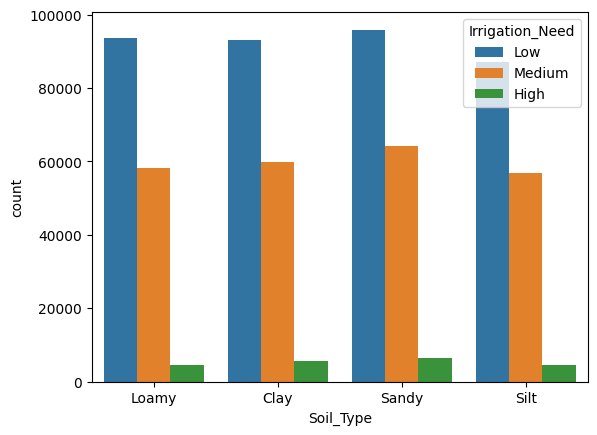

In [11]:
sns.countplot(data=data, x="Soil_Type", hue="Irrigation_Need")

In [14]:
data.groupby("label")["Soil_pH"].mean()

label
-1    6.487805
 0    6.465867
 1    6.578282
Name: Soil_pH, dtype: float64

In [18]:
data.groupby("label")["Soil_Moisture"].mean()

label
-1    43.305902
 0    29.743961
 1    17.669875
Name: Soil_Moisture, dtype: float64

In [19]:
data.groupby("label")["Organic_Carbon"].mean()

label
-1    0.920680
 0    0.926116
 1    0.924143
Name: Organic_Carbon, dtype: float64

In [20]:
data.groupby("label")["Electrical_Conductivity"].mean()

label
-1    1.731755
 0    1.769208
 1    1.690880
Name: Electrical_Conductivity, dtype: float64

In [21]:
data.groupby("label")["Temperature_C"].mean()

label
-1    25.347708
 0    28.886683
 1    34.568134
Name: Temperature_C, dtype: float64

In [22]:
data.groupby("label")["Humidity"].mean()

label
-1    61.949194
 0    61.004887
 1    61.119576
Name: Humidity, dtype: float64

In [23]:
data.groupby("label")["Rainfall_mm"].mean()

label
-1    1500.534313
 0    1444.475028
 1     989.156678
Name: Rainfall_mm, dtype: float64

In [25]:
print(data.groupby("label")["Sunlight_Hours"].mean())
print(data.groupby("label")["Sunlight_Hours"].max())
print(data.groupby("label")["Sunlight_Hours"].min())
# data.groupby("label")["Sunlight_Hours"].max()

label
-1    7.511125
 0    7.521290
 1    7.463138
Name: Sunlight_Hours, dtype: float64
label
-1    11.0
 0    11.0
 1    11.0
Name: Sunlight_Hours, dtype: float64
label
-1    4.0
 0    4.0
 1    4.0
Name: Sunlight_Hours, dtype: float64


In [27]:
print(data.groupby("label")["Wind_Speed_kmh"].mean())
print(data.groupby("label")["Wind_Speed_kmh"].max())
print(data.groupby("label")["Wind_Speed_kmh"].min())

label
-1     9.216424
 0    11.793668
 1    14.642639
Name: Wind_Speed_kmh, dtype: float64
label
-1    20.0
 0    20.0
 1    20.0
Name: Wind_Speed_kmh, dtype: float64
label
-1    0.5
 0    0.5
 1    0.5
Name: Wind_Speed_kmh, dtype: float64


<Axes: xlabel='Crop_Type,label'>

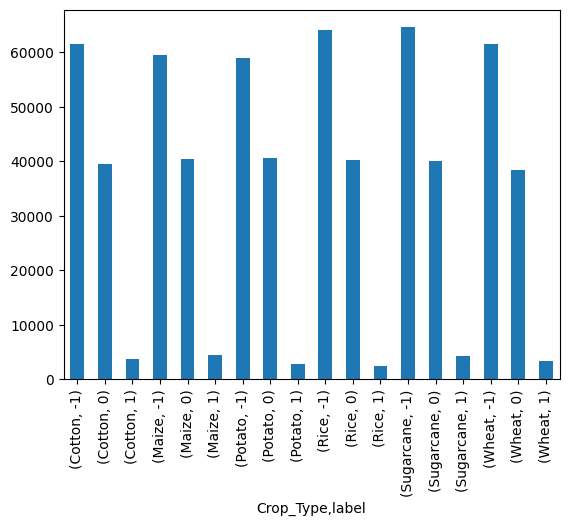

In [29]:
data.groupby("Crop_Type")["label"].value_counts().plot(kind="bar", stacked=True)

<Axes: xlabel='Crop_Growth_Stage,label'>

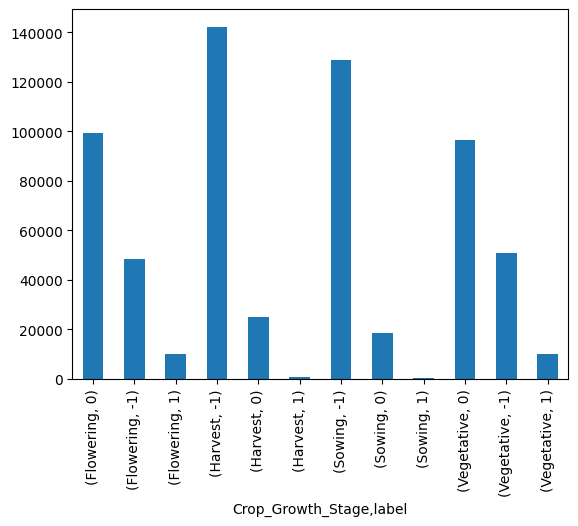

In [30]:
data.groupby("Crop_Growth_Stage")["label"].value_counts().plot(kind="bar", stacked=True)

<Axes: xlabel='Season,label'>

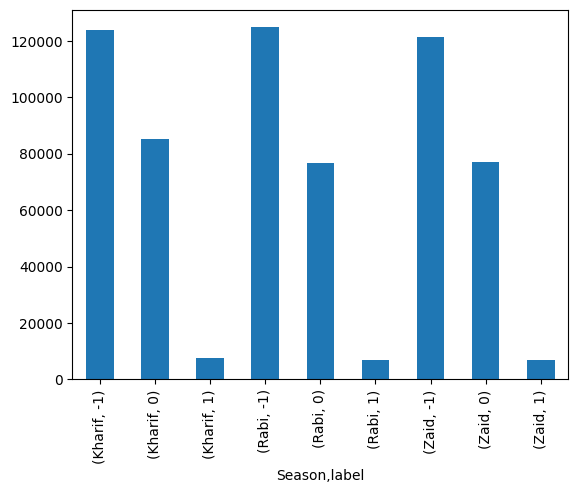

In [31]:
data.groupby("Season")["label"].value_counts().plot(kind="bar", stacked=True)

<Axes: xlabel='Irrigation_Type,label'>

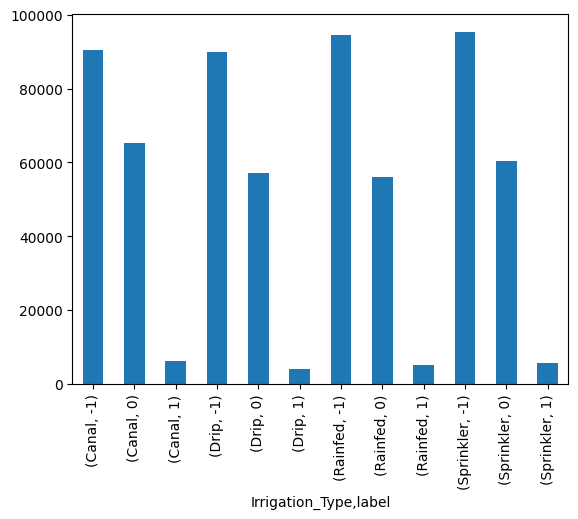

In [32]:
data.groupby("Irrigation_Type")["label"].value_counts().plot(kind="bar", stacked=True)

In [33]:
print(data.groupby("label")["Field_Area_hectare"].mean())

label
-1    7.447241
 0    7.625725
 1    7.530391
Name: Field_Area_hectare, dtype: float64


<Axes: xlabel='Water_Source,label'>

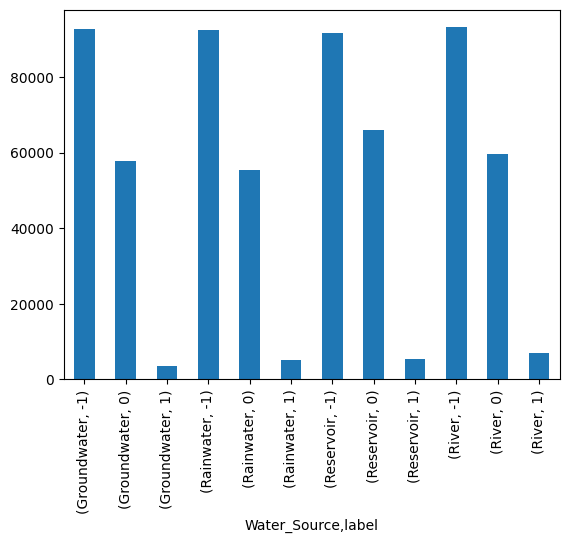

In [34]:
data.groupby("Water_Source")["label"].value_counts().plot(kind="bar", stacked=True)

<Axes: xlabel='Region,label'>

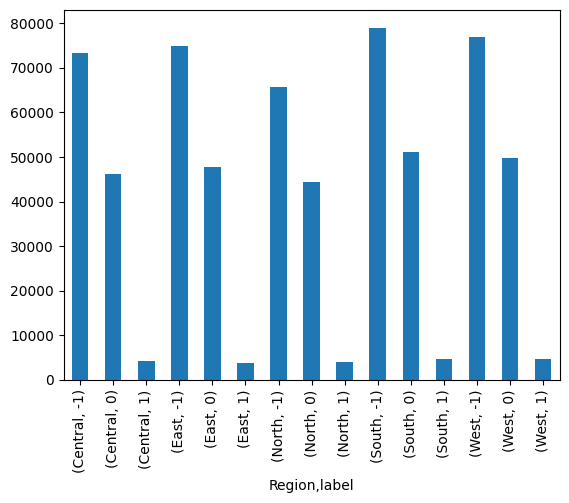

In [35]:
data.groupby("Region")["label"].value_counts().plot(kind="bar", stacked=True)

In [36]:
effective_features = ["Soil_Moisture", "Temperature_C", "Rainfall_mm","Wind_Speed_kmh"]

In [37]:
def train_and_test(X, y):
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

    return accuracy_score(y_test, y_pred)


X = data[effective_features]
y = data["label"]
accuracy = train_and_test(X, y)
print(f"Model Accuracy: {accuracy:.2f}")

/home/awel/coding/newML/irrigation_prediction/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

          -1       0.77      0.83      0.80     73737
           0       0.65      0.61      0.63     48014
           1       0.57      0.23      0.33      4249

    accuracy                           0.72    126000
   macro avg       0.66      0.56      0.59    126000
weighted avg       0.72      0.72      0.72    126000

[[60946 12758    33]
 [18047 29266   701]
 [   89  3174   986]]
Model Accuracy: 0.72


In [38]:
data.shape

(630000, 21)

In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  str    
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  str    
 11  Crop_Growth_Stage        630000 non-null  str    
 12  Season                   630000 non-null  str    
 13  Irrigation_Type          630000 non-null  str    
 14  Water_Source   

In [26]:
data.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,label
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177,-0.553822
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939,0.560178
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000,-1.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000,-1.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000,-1.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000,0.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000,1.000000


In [15]:
data.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'label'],
      dtype='str')